In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Heart Attack Prediction Using Machine Learning

In [85]:
df = pd.read_csv("../data/Medicaldataset.csv")

df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


## Dataset Overview

In [86]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (1319, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 92.9 KB


In [10]:
df.columns

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='str')

## Data Quality Check

In [87]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

Duplicate Rows:
0


## Descriptive Statistics

In [13]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


## Target Variable Distribution

In [89]:
print("Target Distribution:")
print(df["Result"].value_counts())

print("\nTarget Percentage:")
print(df["Result"].value_counts(normalize=True) * 100)

Target Distribution:
Result
positive    810
negative    509
Name: count, dtype: int64

Target Percentage:
Result
positive    61.410159
negative    38.589841
Name: proportion, dtype: float64


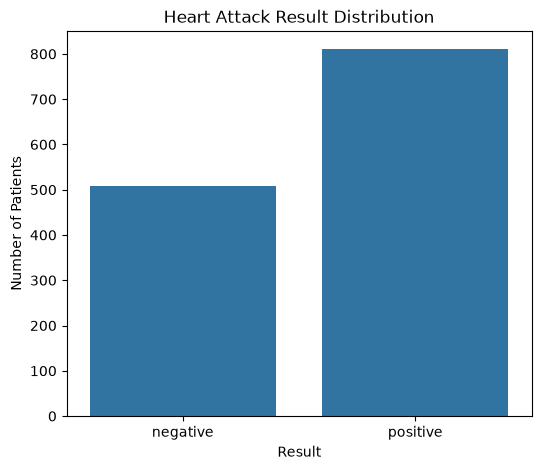

In [90]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="Result")

plt.title("Heart Attack Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Patients")

plt.show()

## Feature Distributions

In [91]:
numeric_columns = [
    "Age",
    "Heart rate",
    "Systolic blood pressure",
    "Diastolic blood pressure",
    "Blood sugar",
    "CK-MB",
    "Troponin"
]

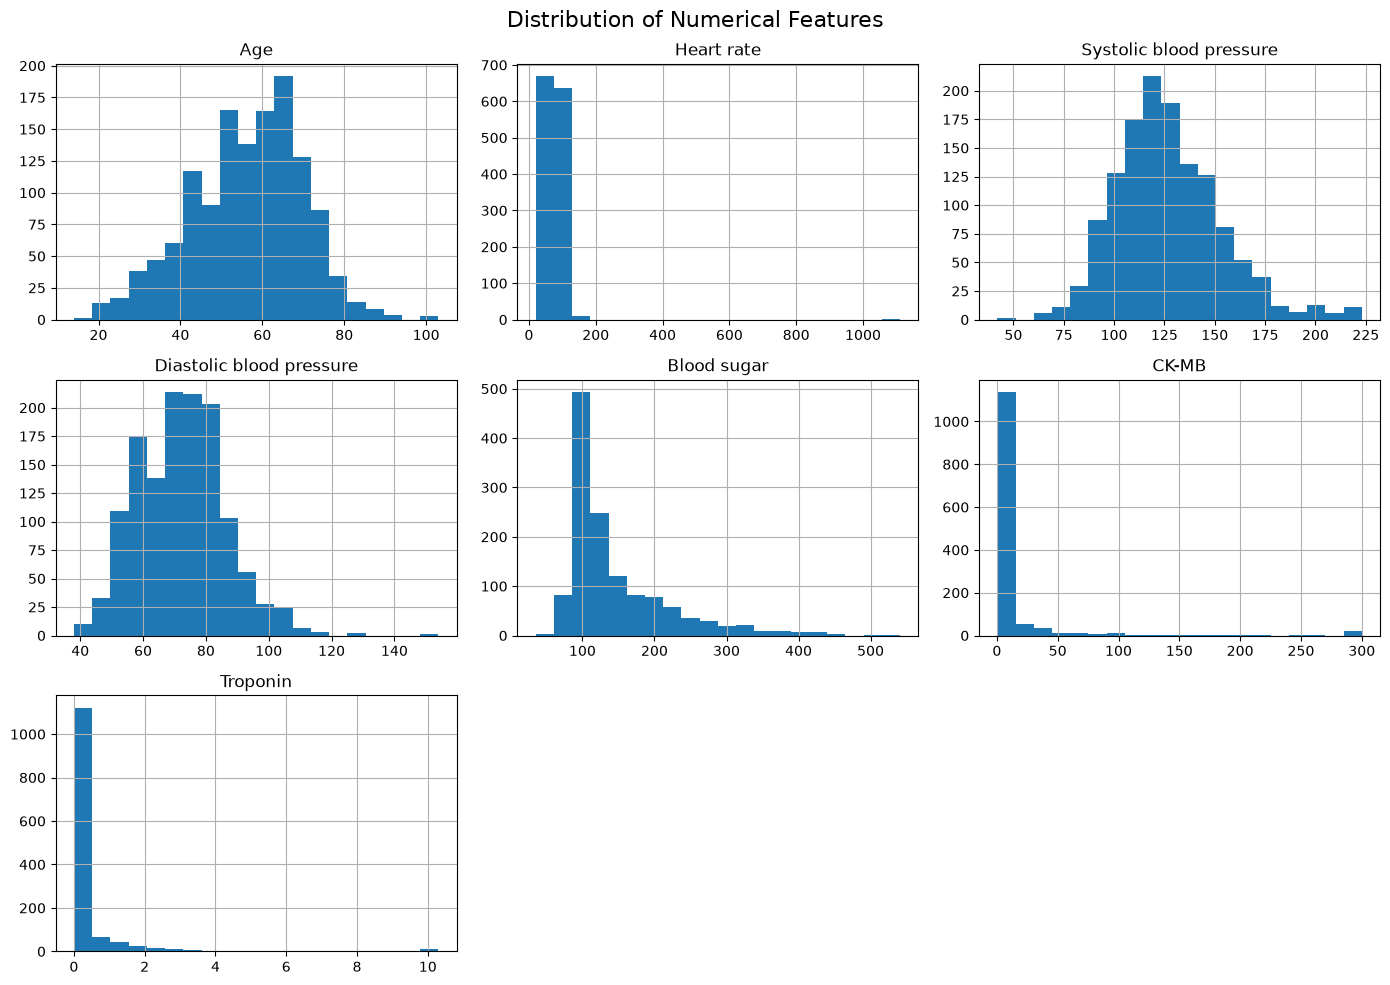

In [92]:
df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Outlier Analysis

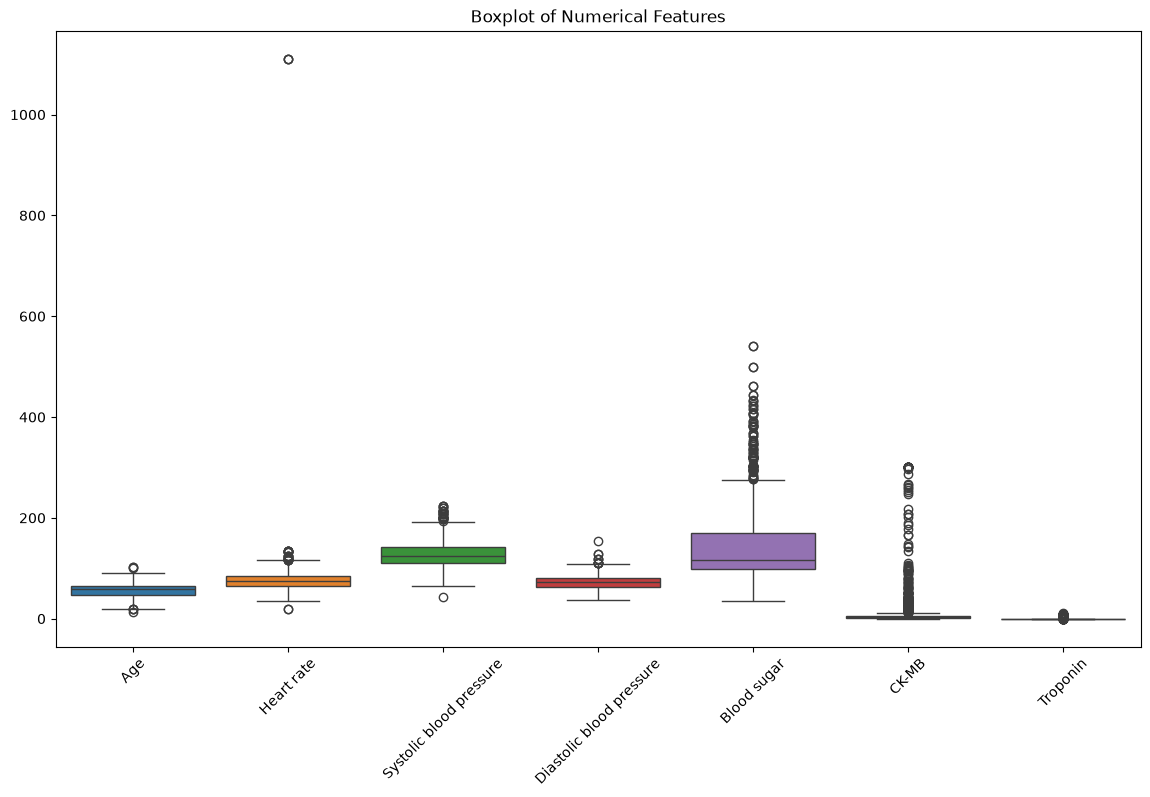

In [95]:
plt.figure(figsize=(14, 8))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [96]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} outliers")

Age: 7 outliers
Heart rate: 30 outliers
Systolic blood pressure: 32 outliers
Diastolic blood pressure: 12 outliers
Blood sugar: 92 outliers
CK-MB: 205 outliers
Troponin: 257 outliers


## Data Preparation

In [97]:
X = df.drop("Result", axis=1)
y = df["Result"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1319, 8)
Target shape: (1319,)


## Target Encoding

In [98]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded values:", np.unique(y_encoded))

Classes: ['negative' 'positive']
Encoded values: [0 1]


In [23]:
pd.Series(y_encoded).value_counts()

1    810
0    509
Name: count, dtype: int64

## Train-Test Split

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1055, 8)
Testing data shape: (264, 8)


## Feature Scaling

In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [101]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### Logistic Regression Predictions

In [102]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions:", y_pred_logistic[:10])

Predictions: [1 0 1 0 0 1 1 1 1 1]


### Logistic Regression Evaluation

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression
-------------------
Accuracy : 0.7992424242424242
Precision: 0.8263473053892215
Recall   : 0.8518518518518519
F1 Score : 0.8389057750759878


### Logistic Regression Confusion Matrix

In [105]:
from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print(logistic_cm)

[[ 73  29]
 [ 24 138]]


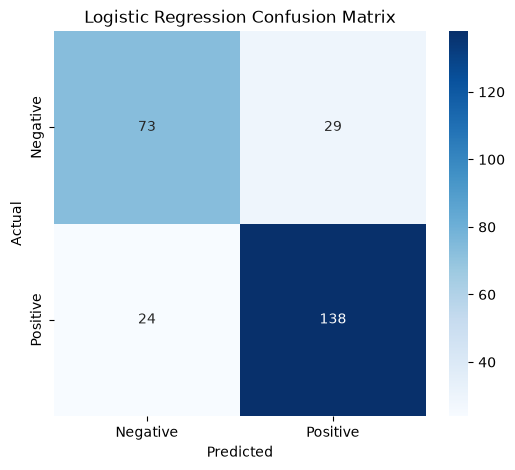

In [106]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Ridge Regression

In [107]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### Ridge Regression Predictions

In [108]:
y_pred_ridge = ridge_model.predict(X_test_scaled)

print("First 10 Ridge predictions:")
print(y_pred_ridge[:10])

First 10 Ridge predictions:
[0.70744251 0.41399267 0.89348927 0.30115431 0.49646734 0.86807599
 0.64743977 0.7139555  0.68949294 0.65304171]


### Ridge Regression Classification

In [109]:
y_pred_ridge_class = (y_pred_ridge >= 0.5).astype(int)

print("First 10 Ridge class predictions:")
print(y_pred_ridge_class[:10])

First 10 Ridge class predictions:
[1 0 1 0 0 1 1 1 1 1]


### Ridge Regression Evaluation

In [110]:
ridge_accuracy = accuracy_score(y_test, y_pred_ridge_class)
ridge_precision = precision_score(y_test, y_pred_ridge_class)
ridge_recall = recall_score(y_test, y_pred_ridge_class)
ridge_f1 = f1_score(y_test, y_pred_ridge_class)

print("Ridge Regression")
print("----------------")
print("Accuracy :", ridge_accuracy)
print("Precision:", ridge_precision)
print("Recall   :", ridge_recall)
print("F1 Score :", ridge_f1)

Ridge Regression
----------------
Accuracy : 0.7045454545454546
Precision: 0.7142857142857143
Recall   : 0.8641975308641975
F1 Score : 0.7821229050279329


### Ridge Regression Confusion Matrix

In [111]:
ridge_cm = confusion_matrix(y_test, y_pred_ridge_class)

print(ridge_cm)

[[ 46  56]
 [ 22 140]]


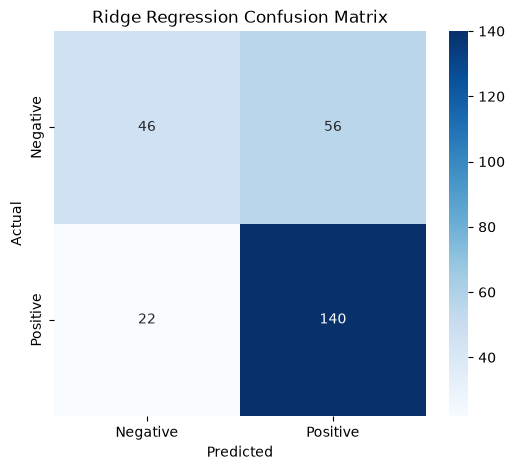

In [112]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    ridge_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Ridge Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Lasso Regression

In [113]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


### Lasso Regression Predictions

In [114]:
y_pred_lasso = lasso_model.predict(X_test_scaled)

print("First 10 Lasso predictions:")
print(y_pred_lasso[:10])

First 10 Lasso predictions:
[0.69419207 0.42533213 0.86568466 0.34001241 0.49244697 0.832304
 0.63444234 0.69580111 0.674737   0.66901399]


### Lasso Regression Classification

In [115]:
y_pred_lasso_class = (y_pred_lasso >= 0.5).astype(int)

print("First 10 Lasso class predictions:")
print(y_pred_lasso_class[:10])

First 10 Lasso class predictions:
[1 0 1 0 0 1 1 1 1 1]


### Lasso Regression Evaluation

In [116]:
lasso_accuracy = accuracy_score(y_test, y_pred_lasso_class)
lasso_precision = precision_score(y_test, y_pred_lasso_class)
lasso_recall = recall_score(y_test, y_pred_lasso_class)
lasso_f1 = f1_score(y_test, y_pred_lasso_class)

print("Lasso Regression")
print("----------------")
print("Accuracy :", lasso_accuracy)
print("Precision:", lasso_precision)
print("Recall   :", lasso_recall)
print("F1 Score :", lasso_f1)

Lasso Regression
----------------
Accuracy : 0.7121212121212122
Precision: 0.7128712871287128
Recall   : 0.8888888888888888
F1 Score : 0.7912087912087912


### Lasso Regression Confusion Matrix

In [117]:
lasso_cm = confusion_matrix(y_test, y_pred_lasso_class)

print(lasso_cm)

[[ 44  58]
 [ 18 144]]


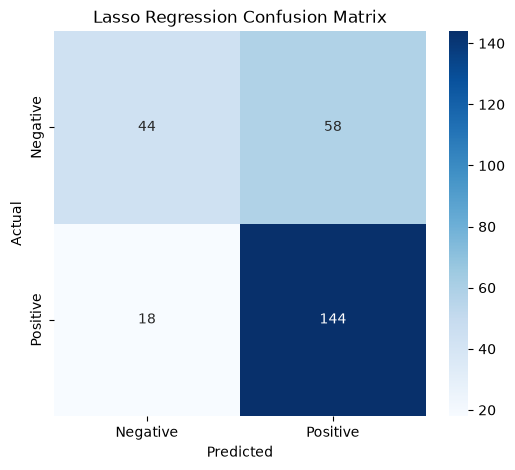

In [118]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    lasso_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Lasso Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Gaussian Naive Bayes

In [119]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[407.,648.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.39,0.61]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.3 ,-0.11,-0.01,..., 0.06,-0.26,-0.29], [ 0.19, 0.07, 0.01,...,-0.03, 0.16, 0.19]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[1.03,1.06,0.87,...,1.1 ,0. ,0.16], [0.89,0.95,1.08,...,0.93,1.56,1.44]]"


### Gaussian Naive Bayes Predictions

In [120]:
y_pred_nb = nb_model.predict(X_test_scaled)

print("First 10 Naive Bayes predictions:")
print(y_pred_nb[:10])

First 10 Naive Bayes predictions:
[1 0 1 0 0 1 1 0 0 0]


### Gaussian Naive Bayes Evaluation

In [121]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)

print("Gaussian Naive Bayes")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Gaussian Naive Bayes
-------------------
Accuracy : 0.696969696969697
Precision: 0.9880952380952381
Recall   : 0.5123456790123457
F1 Score : 0.6747967479674797


### Gaussian Naive Bayes Confusion Matrix

In [122]:
nb_cm = confusion_matrix(y_test, y_pred_nb)

print(nb_cm)

[[101   1]
 [ 79  83]]


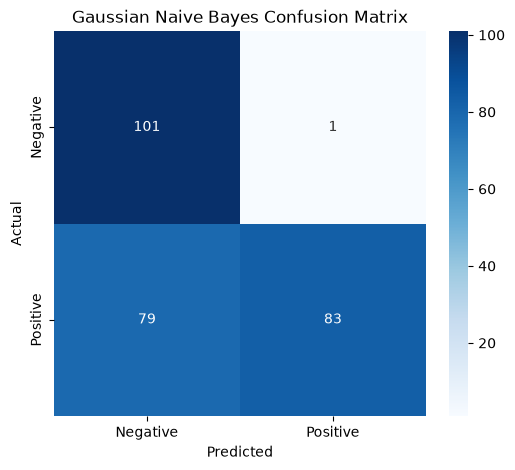

In [123]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Support Vector Machine (SVM)

In [124]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear")

svm_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### SVM Predictions

In [125]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("First 10 SVM predictions:")
print(y_pred_svm[:10])

First 10 SVM predictions:
[1 0 1 0 0 1 1 1 1 1]


### SVM Evaluation

In [126]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("Support Vector Machine")
print("----------------------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Support Vector Machine
----------------------
Accuracy : 0.8106060606060606
Precision: 0.8636363636363636
Recall   : 0.8209876543209876
F1 Score : 0.8417721518987342


### SVM Confusion Matrix

In [127]:
svm_cm = confusion_matrix(y_test, y_pred_svm)

print(svm_cm)

[[ 81  21]
 [ 29 133]]


### SVM Confusion Matrix Heatmap

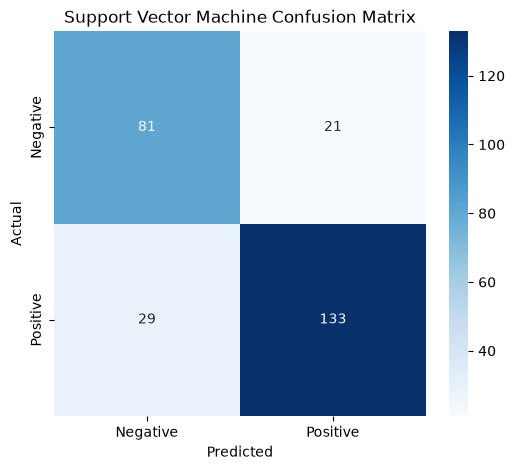

In [128]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Random Forest Predictions

In [130]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[1 0 1 0 0 1 1 1 1 1]


### Random Forest Evaluation

In [131]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------
Accuracy : 0.9848484848484849
Precision: 0.9876543209876543
Recall   : 0.9876543209876543
F1 Score : 0.9876543209876543


### Random Forest Confusion Matrix

In [132]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[100   2]
 [  2 160]]


### Random Forest Confusion Matrix Heatmap

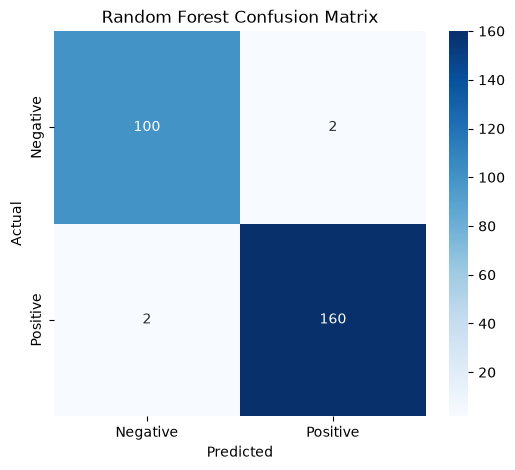

In [133]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Principal Component Analysis (PCA)

### PCA Transformation

In [134]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

Original number of features: 8
Number of PCA components: 2


### PCA Visualization

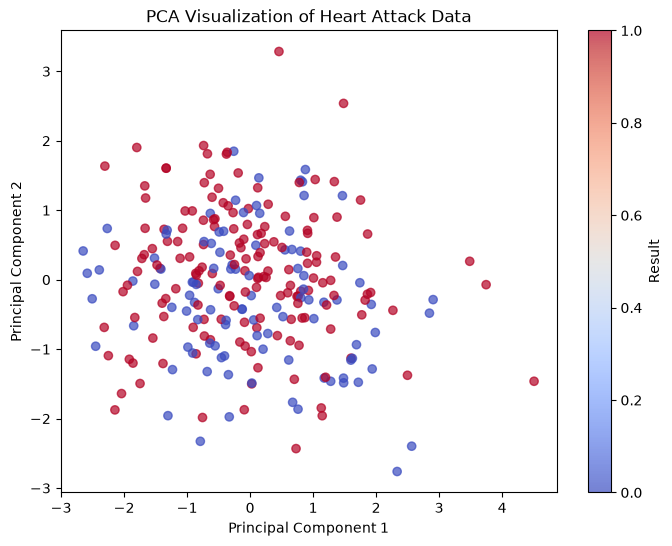

In [135]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Heart Attack Data")
plt.colorbar(label="Result")

plt.show()

### Gaussian Naive Bayes with PCA

In [136]:
nb_pca_model = GaussianNB()

nb_pca_model.fit(X_train_pca, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[407.,648.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.39,0.61]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.601e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 2)","[[-0.04,-0.29], [ 0.03, 0.18]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 2)","[[1.66,1.02], [1.56,1.07]]"


### PCA + Naive Bayes Predictions

In [137]:
y_pred_nb_pca = nb_pca_model.predict(X_test_pca)

print("First 10 PCA + Naive Bayes predictions:")
print(y_pred_nb_pca[:10])

First 10 PCA + Naive Bayes predictions:
[1 1 1 1 0 0 1 1 1 1]


### PCA + Naive Bayes Evaluation

In [138]:
nb_pca_accuracy = accuracy_score(y_test, y_pred_nb_pca)
nb_pca_precision = precision_score(y_test, y_pred_nb_pca)
nb_pca_recall = recall_score(y_test, y_pred_nb_pca)
nb_pca_f1 = f1_score(y_test, y_pred_nb_pca)

print("Gaussian Naive Bayes + PCA")
print("--------------------------")
print("Accuracy :", nb_pca_accuracy)
print("Precision:", nb_pca_precision)
print("Recall   :", nb_pca_recall)
print("F1 Score :", nb_pca_f1)

Gaussian Naive Bayes + PCA
--------------------------
Accuracy : 0.6174242424242424
Precision: 0.6355555555555555
Recall   : 0.8827160493827161
F1 Score : 0.7390180878552972


### PCA + Naive Bayes Confusion Matrix

In [139]:
nb_pca_cm = confusion_matrix(y_test, y_pred_nb_pca)

print(nb_pca_cm)

[[ 20  82]
 [ 19 143]]


### PCA + Naive Bayes Confusion Matrix Heatmap

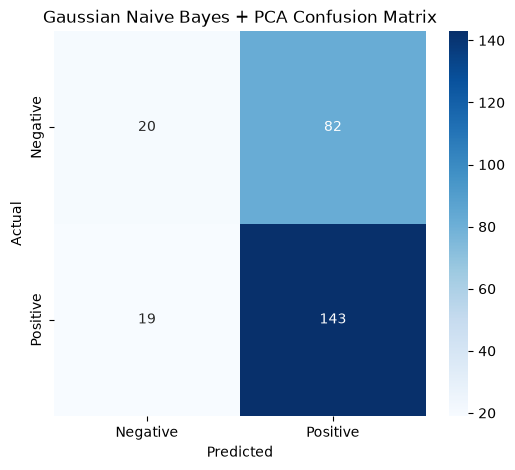

In [140]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nb_pca_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Gaussian Naive Bayes + PCA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Neural Network

### Neural Network Architecture

In [142]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

neural_network = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

neural_network.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

neural_network.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

### Neural Network Training

In [143]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = neural_network.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6469 - loss: 0.6462 - val_accuracy: 0.6351 - val_loss: 0.6408
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6754 - loss: 0.5975 - val_accuracy: 0.6872 - val_loss: 0.6158
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7014 - loss: 0.5690 - val_accuracy: 0.6825 - val_loss: 0.6071
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7085 - loss: 0.5475 - val_accuracy: 0.6967 - val_loss: 0.5942
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7263 - loss: 0.5288 - val_accuracy: 0.7204 - val_loss: 0.5823
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7417 - loss: 0.5078 - val_accuracy: 0.7109 - val_loss: 0.5822
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7559 - loss: 0.4907 - val_accuracy: 0.7204 - val_loss: 0.5758
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7654 - loss: 0.4734 - val_accuracy: 0.

### Neural Network Evaluation

In [144]:
test_loss, test_accuracy = neural_network.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Neural Network")
print("--------------")
print("Test Loss    :", test_loss)
print("Test Accuracy:", test_accuracy)

Neural Network
--------------
Test Loss    : 0.5011793375015259
Test Accuracy: 0.7424242496490479


### Neural Network Predictions

In [145]:
y_pred_nn_prob = neural_network.predict(
    X_test_scaled,
    verbose=0
)

y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int).ravel()

print("First 10 Neural Network predictions:")
print(y_pred_nn[:10])

First 10 Neural Network predictions:
[1 0 1 0 0 1 1 1 1 1]


### Neural Network Classification Metrics

In [146]:
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn)
nn_recall = recall_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)

print("Neural Network")
print("--------------")
print("Accuracy :", nn_accuracy)
print("Precision:", nn_precision)
print("Recall   :", nn_recall)
print("F1 Score :", nn_f1)

Neural Network
--------------
Accuracy : 0.7424242424242424
Precision: 0.7640449438202247
Recall   : 0.8395061728395061
F1 Score : 0.8


### Neural Network Confusion Matrix

In [147]:
nn_cm = confusion_matrix(y_test, y_pred_nn)

print(nn_cm)

[[ 60  42]
 [ 26 136]]


### Neural Network Confusion Matrix Heatmap

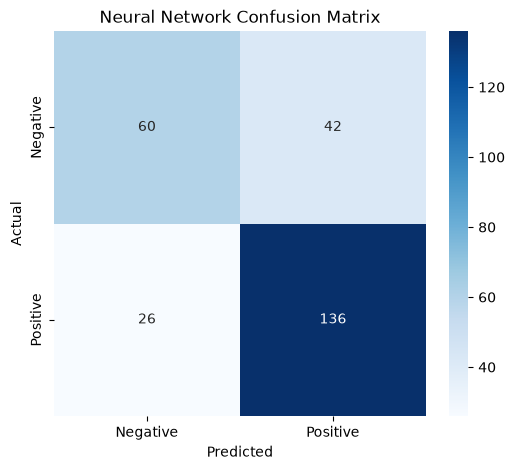

In [148]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    nn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Performance Comparison

In [149]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1
    },
    {
        "Model": "Ridge Regression",
        "Accuracy": ridge_accuracy,
        "Precision": ridge_precision,
        "Recall": ridge_recall,
        "F1 Score": ridge_f1
    },
    {
        "Model": "Lasso Regression",
        "Accuracy": lasso_accuracy,
        "Precision": lasso_precision,
        "Recall": lasso_recall,
        "F1 Score": lasso_f1
    },
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1 Score": nb_f1
    },
    {
        "Model": "Support Vector Machine",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    },
    {
        "Model": "Gaussian Naive Bayes + PCA",
        "Accuracy": nb_pca_accuracy,
        "Precision": nb_pca_precision,
        "Recall": nb_pca_recall,
        "F1 Score": nb_pca_f1
    },
    {
        "Model": "Neural Network",
        "Accuracy": nn_accuracy,
        "Precision": nn_precision,
        "Recall": nn_recall,
        "F1 Score": nn_f1
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.799242,0.826347,0.851852,0.838906
1,Ridge Regression,0.704545,0.714286,0.864198,0.782123
2,Lasso Regression,0.712121,0.712871,0.888889,0.791209
3,Gaussian Naive Bayes,0.696970,0.988095,0.512346,0.674797
4,Support Vector Machine,0.810606,0.863636,0.820988,0.841772
5,Random Forest,0.984848,0.987654,0.987654,0.987654
6,Gaussian Naive Bayes + PCA,0.617424,0.635556,0.882716,0.739018
7,Neural Network,0.742424,0.764045,0.839506,0.800000


### Model Performance Comparison (%)

In [151]:
comparison_df.to_csv(
    "../model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully!")

Model comparison results saved successfully!


## Model Accuracy Comparison

The accuracy of the implemented models is visualized to compare their classification performance on the test dataset.

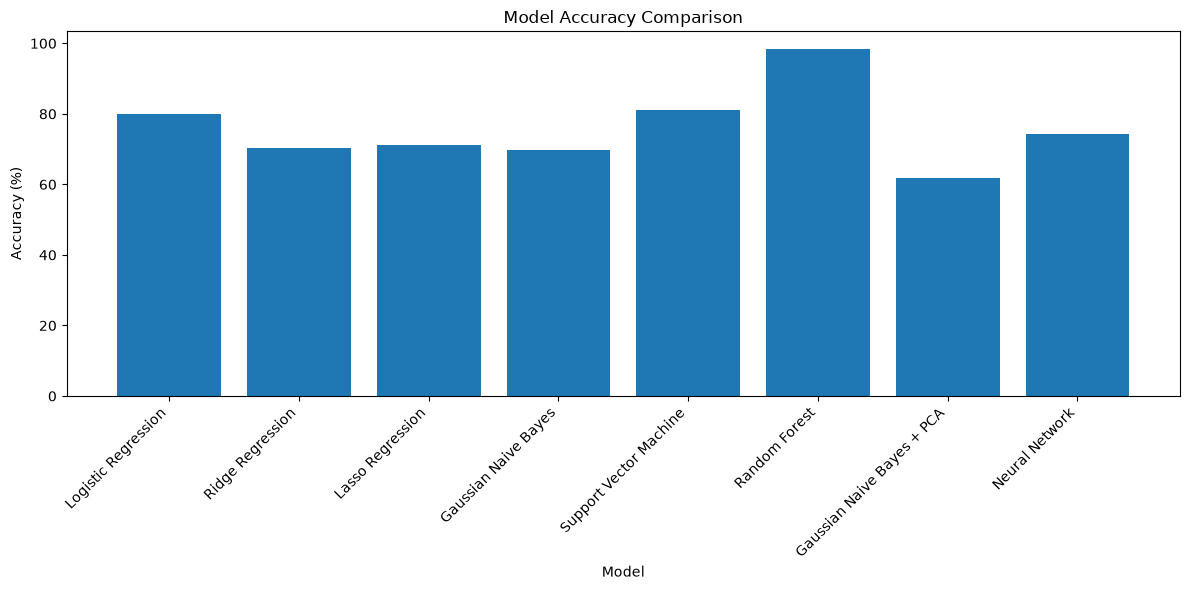

In [152]:
plt.figure(figsize=(12, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Cross-Validation

Cross-validation is used to evaluate the consistency of the Ridge and Lasso regression models across multiple subsets of the training data.

In [153]:
from sklearn.model_selection import cross_val_score

ridge_cv_scores = cross_val_score(
    ridge_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_cv_scores = cross_val_score(
    lasso_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_mse = -ridge_cv_scores
lasso_mse = -lasso_cv_scores

print("Ridge Regression Cross-Validation MSE:")
print(ridge_mse)

print("\nLasso Regression Cross-Validation MSE:")
print(lasso_mse)

print("\nMean Ridge MSE:", ridge_mse.mean())
print("Mean Lasso MSE:", lasso_mse.mean())

Ridge Regression Cross-Validation MSE:
[0.19469332 0.19355873 0.20469268 0.21057999 0.21125874]

Lasso Regression Cross-Validation MSE:
[0.19081152 0.19561555 0.20649943 0.20724382 0.21103138]

Mean Ridge MSE: 0.20295669319314205
Mean Lasso MSE: 0.20224034029913335


## Neural Network Training History

The training and validation accuracy and loss of the neural network are visualized across the training epochs.

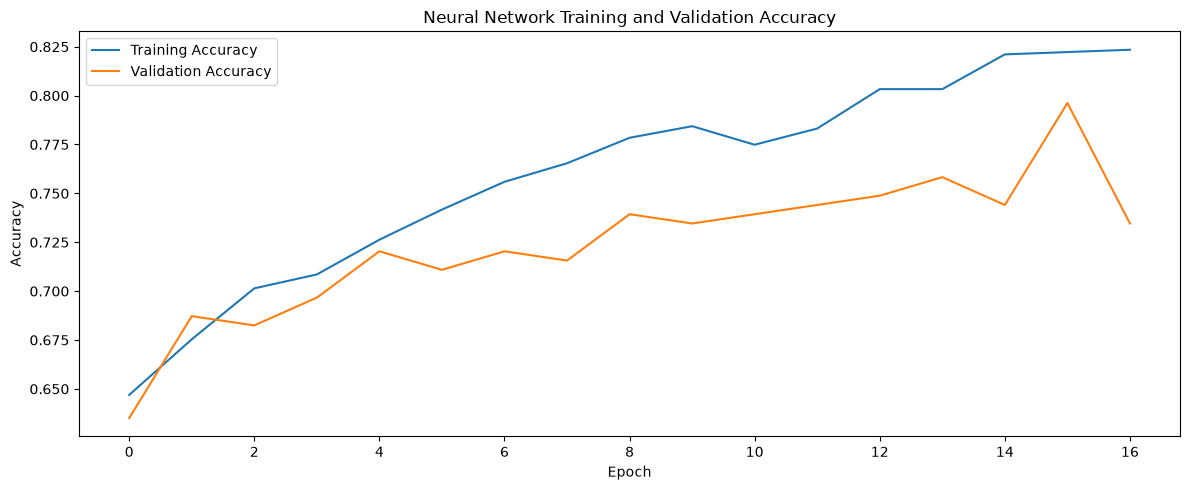

In [154]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Neural Network Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Neural Network Loss

The training and validation loss are visualized to observe the learning behavior of the neural network during training.

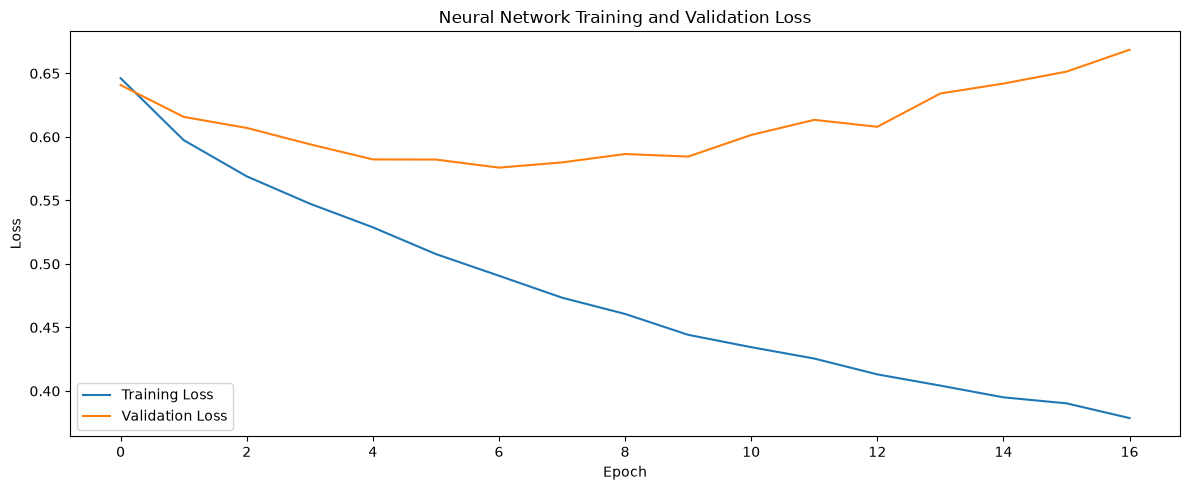

In [155]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Neural Network Confusion Matrix

The confusion matrix is used to visualize the classification performance of the neural network on the test dataset.

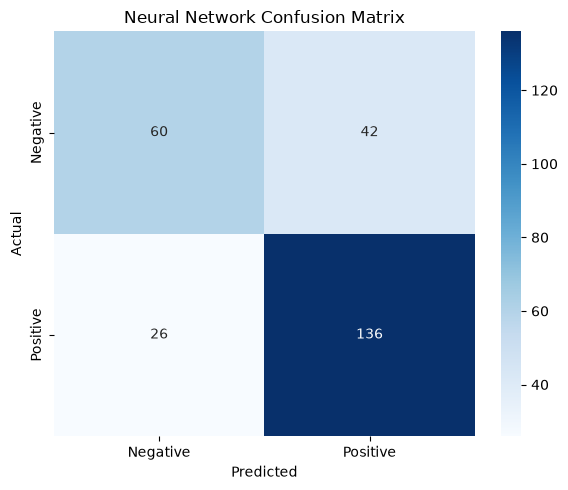

In [156]:
from sklearn.metrics import confusion_matrix

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()